In [2]:
import cobra

import pandas as pd

from Bio.Seq import Seq
from Bio import SeqIO
from Bio.Alphabet import generic_dna

import multiprocessing
from multiprocessing import Pool
# from tqdm import tqdm

import scipy.stats as st
from bs4 import BeautifulSoup
import urllib
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings

import requests, sys, json, re
sys.path.insert(1, '../scripts/') # comment out in python script
from load_environmental_variables import *


load environmental variables
The project root is: /Users/joycebaghdassarian/Documents/UCSD/Lewis_Lab/Projects/human_me/


In [42]:
# polyA tail lengths
polyA_1 = pd.read_excel(local_data_path + 'raw/41592_2019_503_MOESM6_ESM.xlsx', sheet_name = 0, 
                        skiprows=list(range(2)), index_col = 0)
polyA_2 = pd.read_excel(local_data_path + 'raw/41592_2019_503_MOESM6_ESM.xlsx', sheet_name = 1, 
                        skiprows=list(range(2)), index_col = 0)
polyA = pd.DataFrame(index = sorted(set(polyA_1.index.tolist() + polyA_2.index.tolist()))) 
polyA['HeLA_median'] = polyA.index.map(dict(zip(polyA_1.index.tolist(), polyA_1.gene_median_polyA_length.tolist())))
polyA['iPSC_median'] = polyA.index.map(dict(zip(polyA_2.index.tolist(), polyA_2.iPSC_median_polyA_length.tolist())))
polyA['Organoid_median'] = polyA.index.map(dict(zip(polyA_2.index.tolist(), polyA_2.Org_median_polyA_length.tolist())))
polyA['MEAN'] = polyA.mean(axis = 1)
polyA['SD'] = np.sqrt(polyA.loc[:, ['HeLA_median', 'iPSC_median', 'Organoid_median']].var(axis = 1))
polyA.to_csv(local_data_path + 'processed/polyA_length.csv')


# MANE SELECTED transcripts and protein sequences
ids = pd.read_csv(local_data_path + 'raw/MANE.GRCh38.v0.9.summary.txt', sep = '\t')

psim_me = ids.loc[:, ['Ensembl_Gene', 'HGNC_ID', '#NCBI_GeneID', 'Ensembl_nuc', 'Ensembl_prot', 'symbol', 'name', 'chr_strand']]
psim_me.columns = ['ENSG_ID', 'HGNC_ID', 'NCBI_ID', 'ENST_ID', 'ENSP_ID', 'GENE_SYMBOL', 'GENE_NAME', 'CHR_STRAND']

psim_me['POLYA_LENGTH'] = psim_me.GENE_SYMBOL.map(dict(zip(polyA.index.tolist(), polyA.MEAN.tolist())))

In [4]:
# code adapts from 
# https://stackoverflow.com/questions/37487830/how-to-find-probability-distribution-and-parameters-for-real-data-python-3
# https://stackoverflow.com/questions/6620471/fitting-empirical-distribution-to-theoretical-ones-with-scipy-python/16651955#16651955
hyperlink = 'https://docs.scipy.org/doc/scipy/reference/stats.html'
document= BeautifulSoup(urllib.request.urlopen(hyperlink).read()).get_text()
a = document.index('alpha(*args,\xa0**kwds)')
b = document.index('A wrapped Cauchy continuous random variable.')
dist_names = document[a:b].splitlines()[::3]
dist_names = [i.split('(')[0] for i in dist_names]

In [6]:
def get_distribution_fit(data, dist_names, bins = 200):
#     dist_names = ["norm", "exponweib", "weibull_max", "weibull_min", "pareto", "genextreme", 
#                  'gamma', 'beta', 'rayleigh', 'pareto']
    
    distribution_df = pd.DataFrame(columns = ['KS D statistic', 'KS p-value', 'SSE'])
    counter = 0
    for dist_name in dist_names:
        print(counter)
        try:
            with warnings.catch_warnings():
                warnings.filterwarnings('ignore')
                
            distribution = getattr(st, dist_name)
            params = distribution.fit(data)
            y, x = np.histogram(data, bins=bins, density=True)
            x = (x + np.roll(x, -1))[:-1] / 2.0


            D, p = st.kstest(data, dist_name, args=params)

            # Separate parts of parameters
            arg = params[:-2]
            loc = params[-2]
            scale = params[-1]

            # Calculate fitted PDF and error with fit in distribution
            pdf = distribution.pdf(x, loc=loc, scale=scale, *arg)
            sse = np.sum(np.power(y - pdf, 2.0))

            distribution_df.loc[dist_name, :] = [D, p, sse]
        except:
            distribution_df.loc[dist_name, :] = [float('nan')]*3
        counter += 1
    return distribution_df

distribution_df = get_distribution_fit(polyA.MEAN, dist_names = dist_names[:60] + dist_names[61:70] + dist_names[71:])

In [16]:
distribution_df[distribution_df['SSE'] == distribution_df['SSE'].min()].index.tolist()

['johnsonsu']

In [17]:
distribution_df[distribution_df['KS p-value'] == distribution_df['KS p-value'].max()].index.tolist()

['johnsonsu']

In [31]:
# params = st.johnsonsu.fit(polyA.MEAN)
# y, x = np.histogram(polyA.MEAN, bins=200, density=True)
# x = (x + np.roll(x, -1))[:-1] / 2.0
# arg = params[:-2]
# loc = params[-2]
# scale = params[-1]

# # Calculate fitted PDF and error with fit in distribution
# pdf = st.johnsonsu.pdf(x, loc=loc, scale=scale, *arg)

In [35]:
def make_pdf(dist, params, size=10000):
    """Generate distributions's Probability Distribution Function """

    # Separate parts of parameters
    arg = params[:-2]
    loc = params[-2]
    scale = params[-1]

    # Get sane start and end points of distribution
    start = dist.ppf(0.01, *arg, loc=loc, scale=scale) if arg else dist.ppf(0.01, loc=loc, scale=scale)
    end = dist.ppf(0.99, *arg, loc=loc, scale=scale) if arg else dist.ppf(0.99, loc=loc, scale=scale)

    # Build PDF and turn into pandas Series
    x = np.linspace(start, end, size)
    y = dist.pdf(x, loc=loc, scale=scale, *arg)
    pdf = pd.Series(y, x)

    return pdf
pdf = make_pdf(st.johnsonsu,st.johnsonsu.fit(polyA.MEAN) )

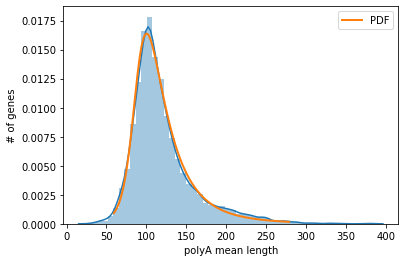

In [41]:
fig, ax = plt.subplots()
g= sns.distplot(polyA.MEAN, ax = ax, kde = True)
ax.set_xlabel('polyA mean length')
ax.set_ylabel('# of genes')
pdf.plot(lw=2, label='PDF', legend=True);

sequence mapping

In [ ]:
# add protein sequences
protein = list(SeqIO.parse(local_data_path + 'raw/MANE.GRCh38.v0.9.select_ensembl_protein.faa', "fasta"))
p_map = dict()
for p in protein:
    p_map[p.id] = str(p.seq)
psim_me['PROTEIN_SEQ'] = psim_me.ENSP_ID.map(p_map)

# add mrna sequence
mrna = list(SeqIO.parse(local_data_path + 'raw/MANE.GRCh38.v0.9.select_ensembl_rna.fna', "fasta"))
m_map = dict()
for m in mrna:
    m_map[m.id] = str(m.seq)
psim_me['MRNA_SEQ'] = psim_me.ENST_ID.map(m_map)

premrna more complicated because FTP doesn't have ENSG to full gene sequence

In [ ]:
# # # add premrna sequence - no FTP file for this, parallelize REST API instead
# def get_premrna_seq(ensg_id, counter):
#     print(counter)
#     try:
#         hyperlink = 'https://rest.ensembl.org/sequence/id/' + ensg_id + '?' 
#         return requests.get(hyperlink, headers={ "Content-Type" : "text/plain"}).text # introns and UTRs
#     except:
#         return float('nan')

# # pool = Pool(processes = multiprocessing.cpu_count())
# # premrna = pool.starmap(get_premrna_seq, zip(psim_me['ENSG_ID'].apply(lambda x: x.split('.')[0]).tolist(), list(range(psim_me.shape[0]))))
# # pool.close()

# # with open(local_data_path + 'interim/premrna_sequences.txt', 'w') as f:
# #     for seq in premrna:
# #         if type(seq) != str:
# #             seq = str(seq)
# #         f.write(seq + '\n')

# premrna = open(local_data_path + 'interim/premrna_sequences.txt', 'r').read().splitlines()
###NOT ALL DOWNLOADED, SO RERUNNING ON THOSE THAT DIDNT DOWNLOAD
# fail = 'You have exceeded the limit of 15 requests per second; please reduce your concurrent connections'
# fail_index = [i for i in range(len(premrna)) if premrna[i] == fail]
# pool = Pool(processes = 4)
# corrected = pool.starmap(get_premrna_seq, zip(psim_me.loc[fail_index, 'ENSG_ID'].apply(lambda x: x.split('.')[0]).tolist(), list(range(psim_me.shape[0]))))
# pool.close()
# for idx, seq in dict(zip(fail_index, corrected)).items():
#     premrna[idx] = seq

# with open(local_data_path + 'interim/premrna_sequences_v2.txt', 'w') as f:
#     for seq in premrna:
#         if type(seq) != str:
#             seq = str(seq)
#         f.write(seq + '\n')
premrna2 = open(local_data_path + 'interim/premrna_sequences_v2.txt', 'r').read().splitlines()
psim_me['PREMRNA_SEQ'] = premrna2

psim_me.loc[psim_me[psim_me.PREMRNA_SEQ == 'nan'].index, 'PREMRNA_SEQ'] = float('nan')

for i in psim_me.index:
    if type(psim_me.loc[i, 'PREMRNA_SEQ']) == str:
        if len(psim_me.loc[i,'MRNA_SEQ']) > len(psim_me.loc[i,'PREMRNA_SEQ']):
            psim_me.loc[i,'PREMRNA_SEQ'] = float('nan')
            

In [ ]:
# formatting
def transcribe(x):
    try: 
        return str(Seq(x).transcribe())
    except:
        return float('nan')

psim_me['MRNA_SEQ'] = psim_me['MRNA_SEQ'].apply(lambda x: transcribe(x))
psim_me['PREMRNA_SEQ'] = psim_me['PREMRNA_SEQ'].apply(lambda x: transcribe(x))

uniprot_map = pd.read_csv(local_data_path + 'raw/gencode.v34.metadata.SwissProt', sep = '\t', header = None)
psim_me['UNIPROT_ID'] = psim_me['ENST_ID'].map(dict(zip(uniprot_map[0].tolist(), uniprot_map[1].tolist())))

psim_human = pd.read_csv(root_path + 'MammalianSecretoryRecon/JUPYTER_NOTEBOOKS/RECON2s_python/PSIM_HUMAN.tab', 
                         sep = '\t')

cols = ['SP', 'DSB', 'GPI', 'NG', 'OG', 'TMD', 'Location']
for col in cols:
    psim_me[col] = psim_me['UNIPROT_ID'].map(dict(zip(psim_human.Entry.tolist(), psim_human[col].tolist())))

for i in psim_me.Location.dropna().index:
    a = psim_me.loc[i, 'Location']
    psim_me.loc[i, 'Location'] = a.split('[')[1].split(']')[0]

The following cell corrects a gene id error in RECON2.2

In [ ]:
# human_model = cobra.io.load_matlab_model(root_path + 'MammalianSecretoryRecon/MODELS/RECON2_2.mat')
# human_model_2 = cobra.io.load_json_model(local_data_path + 'raw/RECON3D.json')

# # two genes in recon2_2 have HGNC:HGNC:### rather than HGNC:###, the following code corrects that issue

# # since the two genes are involved in the same three reactions, simply need to rewrite these three reactions
# # rather than looping through
# genes_to_duplicate = [gene.id for gene in human_model.genes if gene.id.count(':') > 1]
# g0, g1 = genes_to_duplicate[0], genes_to_duplicate[1]  
# g_i = human_model.genes.get_by_id(g0)
# r_i = list(g_i.reactions)
# g_c = human_model.genes.get_by_id(g0[5:])

# # the following line of code gets rid of both genes in genes to duplicate since they are incolved in the same
# # reations
# human_model.remove_reactions(r_i, remove_orphans=True)
# for r in r_i:
#     r0 = r.gene_reaction_rule.replace(g0, g0[5:])
#     r.gene_reaction_rule = r0.replace(g1, g1[5:])
# cobra.io.save_json_model(human_model, local_data_path + 'processed/corrected_recon2_2.json')

human_model = cobra.io.load_json_model(local_data_path + 'processed/corrected_recon2_2.json')

# You are here
must fill out missing machinery sequences

In [ ]:
metabolic_machinery = sorted(set([gene.id for gene in human_model.genes]))

rxnGPR = open(root_path + "MammalianSecretoryRecon/JUPYTER_NOTEBOOKS/RECON2s_python/rxnGPRs_HUMAN.txt").read().splitlines()[1:]
secretory_machinery = []
for i in rxnGPR:
    secretory_machinery += re.findall(r'\d+', i)
secretory_machinery = sorted(set(secretory_machinery))
# ncbi_map = dict(zip(identifiers['NCBI gene ID'].tolist(), identifiers['HGNC ID'].tolist()))
# secretory_machinery = [ncbi_map[i] for i in secretory_machinery]

a = len(set(metabolic_machinery))
b = len(set(metabolic_machinery).difference(psim_me.loc[:, ['PROTEIN_SEQ', 'MRNA_SEQ', 'PREMRNA_SEQ', 'HGNC_ID']].dropna().HGNC_ID.tolist()))

print('{} of {} RECON2.2 machinery mapped'.format(a-b, a))




a = len(set(secretory_machinery))
b = len(set(secretory_machinery).difference(psim_me.loc[:,['PROTEIN_SEQ', 'MRNA_SEQ', 'PREMRNA_SEQ', 'NCBI_ID']].dropna().NCBI_ID.apply(lambda x: x.split('GeneID:')[1]).tolist()))

print('{} of {} secretory machinery mapped'.format(a-b, a))

In [ ]:
psim_me.to_csv(local_data_path + 'processed/psim_me.csv')